In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df=pd.read_csv("/content/drive/MyDrive/titanic.csv")

In [4]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
df = df.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
])

In [6]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [8]:
df=df.dropna()

In [9]:
df.isna().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [12]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Sex"] = label_encoder.fit_transform(df["Sex"])
df["Embarked"] = label_encoder.fit_transform(df["Embarked"])

/tmp/ipykernel_4118/670215741.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Sex"] = label_encoder.fit_transform(df["Sex"])
/tmp/ipykernel_4118/670215741.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Embarked"] = label_encoder.fit_transform(df["Embarked"])


In [13]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,1
886,0,2,1,27.0,0,0,13.0000,2
887,1,1,0,19.0,0,0,30.0000,2
889,1,1,1,26.0,0,0,30.0000,0


In [14]:
from sklearn.preprocessing import MinMaxScaler

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df.to_csv("normalized_data.csv", index=False)

print(df.head())

   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0       0.0     1.0  1.0  0.271174    0.2    0.0  0.014151       1.0
1       1.0     0.0  0.0  0.472229    0.2    0.0  0.139136       0.0
2       1.0     1.0  0.0  0.321438    0.0    0.0  0.015469       1.0
3       1.0     0.0  0.0  0.434531    0.2    0.0  0.103644       1.0
4       0.0     1.0  1.0  0.434531    0.0    0.0  0.015713       1.0


/tmp/ipykernel_4118/2973141195.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_columns] = scaler.fit_transform(df[numeric_columns])


In [15]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.0,1.0,1.0,0.271174,0.2,0.000000,0.014151,1.0
1,1.0,0.0,0.0,0.472229,0.2,0.000000,0.139136,0.0
2,1.0,1.0,0.0,0.321438,0.0,0.000000,0.015469,1.0
3,1.0,0.0,0.0,0.434531,0.2,0.000000,0.103644,1.0
4,0.0,1.0,1.0,0.434531,0.0,0.000000,0.015713,1.0
...,...,...,...,...,...,...,...,...
885,0.0,1.0,0.0,0.484795,0.0,0.833333,0.056848,0.5
886,0.0,0.5,1.0,0.334004,0.0,0.000000,0.025374,1.0
887,1.0,0.0,0.0,0.233476,0.0,0.000000,0.058556,1.0
889,1.0,0.0,1.0,0.321438,0.0,0.000000,0.058556,0.0


In [16]:
x=df.drop("Survived",axis=1)
y=df["Survived"]

In [17]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [19]:
ytestpred=model.predict(x_test)
ytrainpred=model.predict(x_train)

In [25]:
#
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,

    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, ytestpred))
print("Precision:", precision_score(y_test, ytestpred))
print("Recall:", recall_score(y_test, ytestpred))
print("F1-score:", f1_score(y_test, ytestpred))


print("Confusion Matrix:")
print(confusion_matrix(y_test, ytestpred))

Accuracy: 0.7832167832167832
Precision: 0.8076923076923077
Recall: 0.6666666666666666
F1-score: 0.7304347826086957
Confusion Matrix:
[[70 10]
 [21 42]]


In [26]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(x_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.8248015873015874


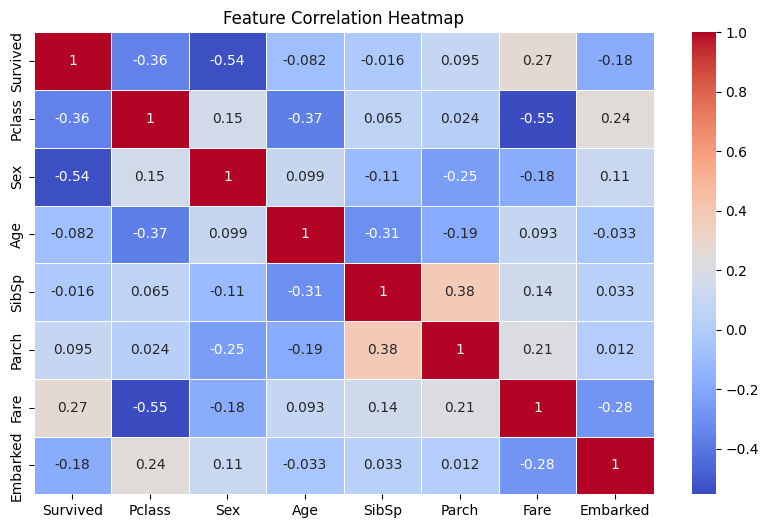

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

corr = df.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

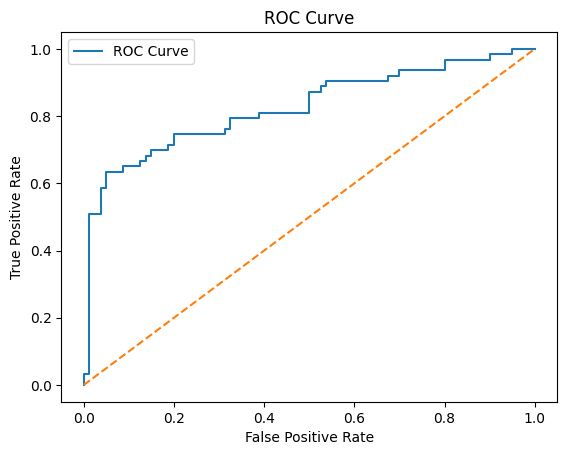

In [27]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [30]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": ytestpred,
    "Survival_Probability": y_prob
})

results.head()

,Actual,Predicted,Survival_Probability
0,1.0,1.0,0.945531
1,1.0,1.0,0.879514
2,0.0,0.0,0.316186
3,1.0,1.0,0.929176
4,0.0,0.0,0.247251
